# Imports

In [14]:
from FeatureCloud.app.engine.app import AppState, app_state, Role
import time
import bios
import pandas as pd
import numpy as np
import sklearn as sk
from sklearn.linear_model import LinearRegression

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from Autoencoder_classes import Encoder, Decoder, GOAE, ClusteringLayer, extract_latent_space, orthogonality_loss

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from torch import nn
from sklearn.cluster import KMeans

from sklearn.metrics import adjusted_rand_score, accuracy_score, recall_score, f1_score, precision_score

# Read and split normalized dataset

In [17]:
df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep='\t', index_col=0)
df

C:\Users\david\AppData\Local\Temp\ipykernel_13388\3676504475.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep='\t', index_col=0)


,01CPTAC_1,01CPTAC_2,01CPTAC_3,01CPTAC_4,01CPTAC_5,01CPTAC_6,01CPTAC_7,01CPTAC_8,01CPTAC_9,01CPTAC_10,...,13CPTAC_1,13CPTAC_2,13CPTAC_3,13CPTAC_4,13CPTAC_5,13CPTAC_6,13CPTAC_7,13CPTAC_8,13CPTAC_9,13CPTAC_10
0,0.701362,-1.032968,0.44756,0.92818,0.573821,-1.107313,-1.41547,-0.663002,0.025081,1.542748,...,-0.341029,0.367947,0.380557,0.178338,0.246717,1.176596,1.255426,-0.061805,-1.144361,-2.058388
1,2.365221,-0.703355,0.292596,-0.639314,0.274932,-0.817895,-1.081457,0.3354,-0.45452,0.42839,...,1.621392,-0.06675,1.616485,-0.281558,-0.009805,0.036282,-1.296309,-0.95651,-0.986464,0.323236
2,0.794181,-1.35902,-0.440742,0.955241,0.544417,-0.757902,-1.49429,-0.338234,1.039336,1.057011,...,0.660141,0.725854,1.119182,-0.712228,0.612471,0.696695,0.196962,-0.019711,-1.658432,-1.620935
3,1.867337,-0.141384,0.553497,0.06251,-0.081055,0.230644,-2.157068,-0.643006,0.08704,0.221485,...,0.850038,-0.609254,2.009378,-0.827816,0.518568,0.441824,0.020362,-0.335359,-1.517909,-0.549831
4,2.265564,-1.084166,-0.709763,0.345636,-0.334825,0.339006,0.673064,-0.524631,-1.051931,0.082046,...,0.635782,-1.276797,0.456656,1.333118,0.248196,-1.252952,-1.249321,-0.55758,1.048278,0.614619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10561,2.436067655941897,0.25839636490354206,0.2543609807773492,-0.11814050676898763,-0.2951251025985929,-0.6218672528432535,-0.9830450533613752,0.23874295061272283,-1.192650196665077,0.023260160001785594,...,0.9656978817844211,-0.9022976378963742,1.4750967170604077,1.3923194012190885,0.4566719460277087,-0.803978600860892,-1.26281425163763,-0.2790794627037255,-0.7063140045767798,-0.33530198841621256
10562,0.8453734480227291,-0.8930828964002628,0.12955218147744502,-0.7146064037242827,-0.007667297645726107,0.48506074607181976,-2.1481169797010367,0.36156456898356115,0.7538316010871887,1.1880910318285292,...,1.9120552052770763,-0.09683753836028669,0.28447199573460497,1.2229535890179952,-0.054722195328275186,0.2656297586110062,-0.6576004219541816,-0.3845921365770148,-1.265572483597312,-1.2257857728236148
10563,0.6100639996949794,-1.3863153594249709,1.2052870335945718,0.14955442369628713,0.5564875421231679,-1.3135730429298373,-0.6588048821945651,-1.0028422824737502,0.7426777857606601,1.0974647821534407,...,0.17168892451208204,-0.3155580490573324,-0.48927953797212265,1.361518482969639,1.1806283899193284,-1.261381119221445,0.0986411548269918,1.2989800370575564,-1.0688480871134933,-0.9763901959212694


In [4]:
##Data Split for 3 clients
part1 = df.iloc[:, :40].T
part2 = df.iloc[:, 40:80].T
part3 = df.iloc[:, 80:130].T

part1_conditions = part1.iloc[:, -1]
part2_conditions = part2.iloc[:, -1]
part3_conditions = part3.iloc[:, -1]

part1.drop(part1.columns[len(part1.columns)-1], axis=1, inplace=True)
part2.drop(part2.columns[len(part2.columns)-1], axis=1, inplace=True)
part3.drop(part3.columns[len(part3.columns)-1], axis=1, inplace=True)

In [18]:
##Data Split for 5 clients
s5_part1 = df.iloc[:, :30].T
s5_part2 = df.iloc[:, 30:50].T
s5_part3 = df.iloc[:, 50:80].T
s5_part4 = df.iloc[:, 80:110].T
s5_part5 = df.iloc[:, 110:130].T

s5_part1_conditions = s5_part1.iloc[:, -1]
s5_part2_conditions = s5_part2.iloc[:, -1]
s5_part3_conditions = s5_part3.iloc[:, -1]
s5_part4_conditions = s5_part4.iloc[:, -1]
s5_part5_conditions = s5_part5.iloc[:, -1]

s5_part1.drop(s5_part1.columns[len(s5_part1.columns)-1], axis=1, inplace=True)
s5_part2.drop(s5_part2.columns[len(s5_part2.columns)-1], axis=1, inplace=True)
s5_part3.drop(s5_part3.columns[len(s5_part3.columns)-1], axis=1, inplace=True)
s5_part4.drop(s5_part4.columns[len(s5_part4.columns)-1], axis=1, inplace=True)
s5_part5.drop(s5_part5.columns[len(s5_part5.columns)-1], axis=1, inplace=True)

# Export split datasets into client folders

In [5]:
##Export Split 3 Clients
export1 = part1.to_csv('data/client1/realdata.csv', sep=';')
export2 = part2.to_csv('data/client2/realdata.csv', sep=';')
export3 = part3.to_csv('data/client3/realdata.csv', sep=';')
export_meta1 = part1_conditions.to_csv('data/client1/realmetadata.csv', sep=';')
export_meta2 = part2_conditions.to_csv('data/client2/realmetadata.csv', sep=';')
export_meta3 = part3_conditions.to_csv('data/client3/realmetadata.csv', sep=';')

In [19]:
##Export Split 5 Clients
export1 = s5_part1.to_csv('data/client1/5splitrealdata.csv', sep=';')
export2 = s5_part2.to_csv('data/client2/5splitrealdata.csv', sep=';')
export3 = s5_part3.to_csv('data/client3/5splitrealdata.csv', sep=';')
export4 = s5_part4.to_csv('data/client4/5splitrealdata.csv', sep=';')
export5 = s5_part5.to_csv('data/client5/5splitrealdata.csv', sep=';')

export_meta1 = s5_part1_conditions.to_csv('data/client1/5splitrealmetadata.csv', sep=';')
export_meta2 = s5_part2_conditions.to_csv('data/client2/5splitrealmetadata.csv', sep=';')
export_meta3 = s5_part3_conditions.to_csv('data/client3/5splitrealmetadata.csv', sep=';')
export_meta3 = s5_part4_conditions.to_csv('data/client4/5splitrealmetadata.csv', sep=';')
export_meta3 = s5_part5_conditions.to_csv('data/client5/5splitrealmetadata.csv', sep=';')

In [3]:
df1 = pd.read_csv('data/client1/realmetadata.csv', sep=';', index_col=0)
df1


,Conditions
01CPTAC_1,Not Reported
01CPTAC_2,Primary Tumor
01CPTAC_3,Primary Tumor
01CPTAC_4,Primary Tumor
01CPTAC_5,Primary Tumor
01CPTAC_6,Primary Tumor
01CPTAC_7,Solid Tissue Normal
01CPTAC_8,Primary Tumor
01CPTAC_9,Primary Tumor
01CPTAC_10,Primary Tumor


# Testing aggregated models:

In [20]:
df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep = '\t', index_col=0)
conditions = df.T.drop(columns=['Conditions'])
df = df.T.drop(columns=['Conditions'])
sample_data_normalized = df.reset_index(drop=True).to_numpy(dtype=np.float32)
sample_data_normalized = np.nan_to_num(sample_data_normalized)
proteomics_tensor = torch.tensor(sample_data_normalized, dtype=torch.float32)

input_dim = proteomics_tensor.shape[1]

latent_dim = 10
hidden_dim_1 = 500
hidden_dim_2 = 2000
hidden_dim_3 = 500
n_clusters = 2
autoencoder = GOAE(input_dim, latent_dim, hidden_dim_1=hidden_dim_1, hidden_dim_2=hidden_dim_2, hidden_dim_3=hidden_dim_3)
#clustering_layer = ClusteringLayer(n_clusters, latent_dim)



# Initialize optimizers
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
autoencoder.load_state_dict(torch.load('data/tests/5 client test cptac normalization/_state_dict', weights_only=True))

C:\Users\david\AppData\Local\Temp\ipykernel_13388\1671610684.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_dataset_normalized_by_cptac.tsv', sep = '\t', index_col=0)


<All keys matched successfully>

In [21]:
latent_representations = extract_latent_space(autoencoder, proteomics_tensor)
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
clusters = kmeans.fit_predict(latent_representations)

In [10]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
conditions = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)
conditions = conditions.T.iloc[:, -1]
conditions = conditions.dropna();
conditions

C:\Users\david\AppData\Local\Temp\ipykernel_13388\1733738910.py:1: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130) have mixed types. Specify dtype option on import or set low_memory=False.
  conditions = pd.read_csv('data/real_dataset_normalized.tsv', sep = '\t', index_col=0)


01CPTAC_1             Not Reported
01CPTAC_2            Primary Tumor
01CPTAC_3            Primary Tumor
01CPTAC_4            Primary Tumor
01CPTAC_5            Primary Tumor
                      ...         
13CPTAC_6            Primary Tumor
13CPTAC_7            Primary Tumor
13CPTAC_8            Primary Tumor
13CPTAC_9      Solid Tissue Normal
13CPTAC_10     Solid Tissue Normal
Name: Conditions, Length: 130, dtype: object

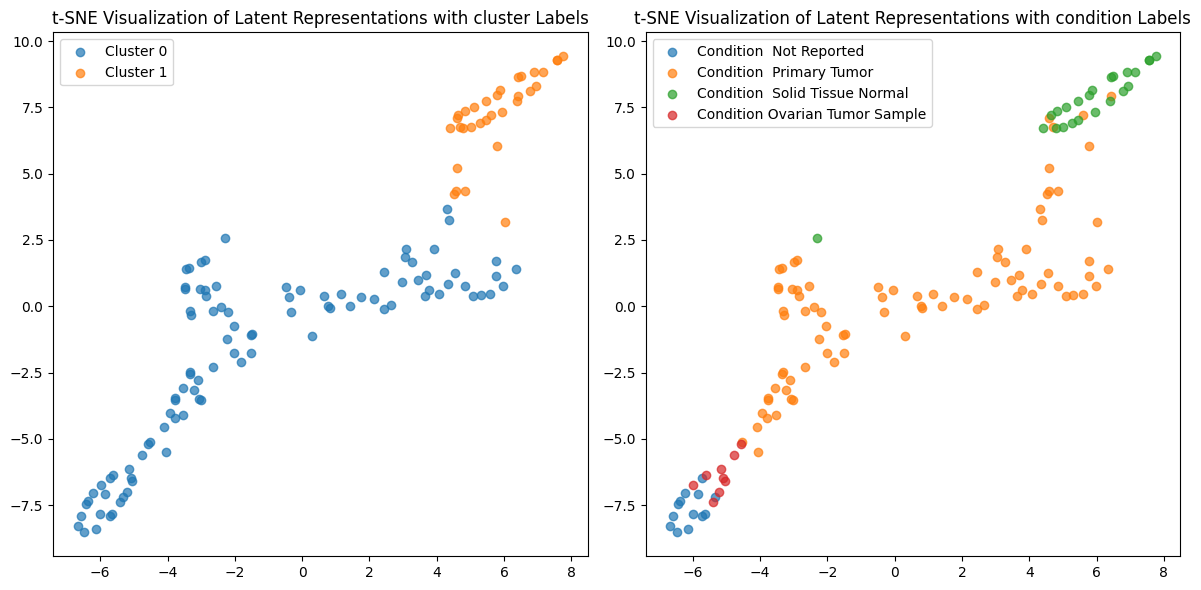

In [12]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluation


In [15]:
index = (conditions ==' Primary Tumor') + (conditions == ' Solid Tissue Normal')

filtered_space = latent_representations[index, :]
filtered_conditions = conditions[index]

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=22)
dbscan = DBSCAN(eps=0.06)
optics = OPTICS(min_samples=5, xi=0.085, min_cluster_size=0.05)

dbscan_clustering = dbscan.fit(filtered_space).labels_
optics_clustering = optics.fit(filtered_space).labels_
kmeans_clustering = kmeans.fit(filtered_space).labels_


3 Client Test

In [16]:
condition_map = {
    ' Primary Tumor' : 0,
    ' Solid Tissue Normal' : 1
}

encoded_conditions = np.vectorize(condition_map.get)(filtered_conditions)
equality1 = encoded_conditions == kmeans_clustering
equality2 = encoded_conditions != kmeans_clustering
# swich if cluster lables (name of cluster is random)
if np.sum(equality1) < np.sum(equality2):
    encoded_conditions = -1*encoded_conditions + 1


accuracy = accuracy_score(kmeans_clustering, encoded_conditions)
recall = recall_score(kmeans_clustering, encoded_conditions)
f1 = f1_score(kmeans_clustering, encoded_conditions)
precision = precision_score(kmeans_clustering, encoded_conditions)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")

Accuracy: 0.9259259259259259
Recall: 0.9873417721518988
F1 Score: 0.9512195121951219
Precision: 0.9176470588235294


5 Client Test

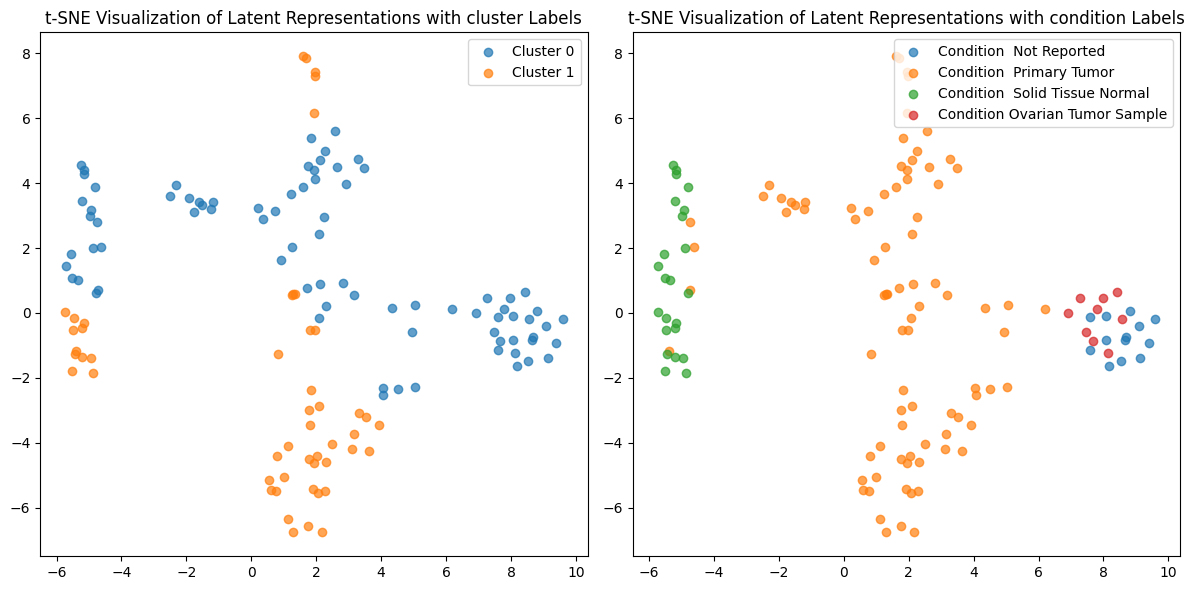

In [23]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=0)
latent_2d = tsne.fit_transform(latent_representations)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for cluster in set(clusters):
    indices = (clusters == cluster)
    axes[0].scatter(latent_2d[indices, 0], latent_2d[indices, 1], label=f'Cluster {cluster}', alpha=0.7)
axes[0].set_title('t-SNE Visualization of Latent Representations with cluster Labels')
axes[0].legend()

conditions = conditions.values
unique_conditions = np.unique(conditions)
for condition in unique_conditions:
    indices = (conditions == condition)
    axes[1].scatter(
        latent_2d[indices, 0],
        latent_2d[indices, 1],
        label=f'Condition {condition}',
        alpha=0.7
    )
axes[1].set_title('t-SNE Visualization of Latent Representations with condition Labels')
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
condition_map = {
    ' Primary Tumor' : 0,
    ' Solid Tissue Normal' : 1
}

encoded_conditions = np.vectorize(condition_map.get)(filtered_conditions)
equality1 = encoded_conditions == kmeans_clustering
equality2 = encoded_conditions != kmeans_clustering
# swich if cluster lables (name of cluster is random)
if np.sum(equality1) < np.sum(equality2):
    encoded_conditions = -1*encoded_conditions + 1


accuracy = accuracy_score(kmeans_clustering, encoded_conditions)
recall = recall_score(kmeans_clustering, encoded_conditions)
f1 = f1_score(kmeans_clustering, encoded_conditions)
precision = precision_score(kmeans_clustering, encoded_conditions)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")

Accuracy: 0.9259259259259259
Recall: 0.9873417721518988
F1 Score: 0.9512195121951219
Precision: 0.9176470588235294
